# Full pulse schedule depletion simulation

This example performs a depletion/transmutation/activation simulation

The simulation has been accelerated by making use of the IndependentOperator instead of the CoupledOperator.

This is an approximation so is less accurate but it is much faster.

This approach performs just a single transport simulation and obtains reactions rates once and assumes that they remain constant.

If the materials don't change significantly during the irradiation this is a reasonable approximation.

Fission fuel pins would perhaps require the full CoupledOperator while the majority of fusion simulations are suitable for the IndependentOperator

More details on both Operators in the docs
https://docs.openmc.org/en/stable/usersguide/depletion.html#transport-independent-depletion

In [1]:
# remove any old files
!rm settings.xm model.xml materials.xml geometry.xml settings.xml

import matplotlib.pyplot as plt
import openmc
import openmc.deplete
import math
from pathlib import Path
# Setting the cross section path to the correct location in the docker image.
# If you are running this outside the docker image you will have to change this path to your local cross section path.
openmc.config['cross_sections'] = Path.home() / 'nuclear_data' / 'cross_sections.xml'
# This chain file was downloaded using the download_endf_chain script that is included in the openmc_data package https://github.com/openmc-data-storage/openmc_data\n",
# this file tells openmc the decay paths between isotopes including probabilities of different routes and half lives
# To download this xml file you can run these commands
# pip install openmc_data
# download_endf_chain -d nuclear_data -r b8.0
openmc.config['chain_file'] = Path.home() / 'nuclear_data' / 'chain-endf-b8.0.xml'

rm: cannot remove 'settings.xm': No such file or directory
rm: cannot remove 'model.xml': No such file or directory


Creates a simple material which we will deplete

In [2]:
my_material = openmc.Material(material_id=1) 
my_material.add_element('Ag', 1, percent_type='ao')
my_material.set_density('g/cm3', 10.49)

As we are doing a depletion simulation we must set the material volume and the .depletion to True

In [3]:
sphere_radius = 100
volume_of_sphere = (4/3) * math.pi * math.pow(sphere_radius, 3)
my_material.volume = volume_of_sphere  # a volume is needed so openmc can find the number of atoms in the cell/material
my_material.depletable = True  # depletable = True is needed to tell openmc to update the material with each time step
materials = openmc.Materials([my_material])

makes a simple sphere surface and cell

In [4]:
sph1 = openmc.Sphere(r=sphere_radius, boundary_type='vacuum')
shield_cell = openmc.Cell(region=-sph1)
shield_cell.fill = my_material
geometry = openmc.Geometry([shield_cell])

creates a simple point source

In [5]:
source = openmc.IndependentSource()
source.space = openmc.stats.Point((0, 0, 0))
source.angle = openmc.stats.Isotropic()
source.energy = openmc.stats.Discrete([14e6], [1])
source.particles = 'neutron'

defines the simulation settings

In [6]:
settings = openmc.Settings()
settings.batches = 10
settings.inactive = 0
settings.particles = 1000
settings.source = source
settings.run_mode = 'fixed source'

builds the model combining the materials, geometry and settings into one object

In [7]:
model = openmc.Model(geometry, materials, settings)

this does perform particle transport but just to get the flux and micro xs

In [8]:
flux_in_each_group, micro_xs = openmc.deplete.get_microxs_and_flux(
    model=model,
    domains=[shield_cell],
    energies=[0, 30e6], # one energy bin from 0 to 30MeV
    chain_file=openmc.config['chain_file'],
)

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading cross sections XML file...
 Reading Ag107 from /home/jon/nuclear_data/neutron/Ag107.h5
 Reading Ag109 from /home/jon/nuclear_data/neutron/Ag109.h5


 Minimum neutron data temperature: 294.0 K
 Maximum neutron data temperature: 294.0 K
 Reading H1 from /home/jon/nuclear_data/neutron/H1.h5
 Reading H2 from /home/jon/nuclear_data/neutron/H2.h5
 Reading H3 from /home/jon/nuclear_data/neutron/H3.h5
 Reading He3 from /home/jon/nuclear_data/neutron/He3.h5
 Reading He4 from /home/jon/nuclear_data/neutron/He4.h5
 Reading Li6 from /home/jon/nuclear_data/neutron/Li6.h5
 Reading Li7 from /home/jon/nuclear_data/neutron/Li7.h5
 Reading Be7 from /home/jon/nuclear_data/neutron/Be7.h5
 Reading Be9 from /home/jon/nuclear_data/neutron/Be9.h5


 Reading B10 from /home/jon/nuclear_data/neutron/B10.h5
 Reading B11 from /home/jon/nuclear_data/neutron/B11.h5
 Reading C12 from /home/jon/nuclear_data/neutron/C12.h5


 Reading C13 from /home/jon/nuclear_data/neutron/C13.h5
 Reading N14 from /home/jon/nuclear_data/neutron/N14.h5


...

 Simulating batch 7


 Simulating batch 8


 Simulating batch 9


 Simulating batch 10


 Creating state point statepoint.10.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 1.1246e+02 seconds
   Reading cross sections          = 2.1324e-01 seconds
 Total time in simulation          = 1.0316e+02 seconds
   Time in transport only          = 1.0312e+02 seconds
   Time in active batches          = 1.0316e+02 seconds
   Time accumulating tallies       = 1.8084e-02 seconds
   Time writing statepoints        = 1.2909e-02 seconds
 Total time for finalization       = 2.1088e-02 seconds
 Total time elapsed                = 2.1637e+02 seconds
 Calculation Rate (active)         = 96.9389 particles/second

 ============================>     RESULTS     <============================

 Leakage Fraction            = 0.00010 +/- 0.00010



constructing the operator, note we pass in the flux and micro xs calculated earlier

In [9]:
operator = openmc.deplete.IndependentOperator(
    materials=materials,
    fluxes=[i[0] for i in flux_in_each_group],
    micros=micro_xs,
    reduce_chain_level=5,
    normalization_mode="source-rate"
)

We define timesteps together with the source rate to make it clearer

In [10]:
timesteps_and_source_rates = [
    (24, 1e20),
    (24, 1e20),
    (24, 1e20),
    (24, 1e20),
    (24, 1e20),  # should saturate Ag110 here as it has been irradiated for over 5 halflives
    (24, 1e20),
    (24, 1e20),
    (24, 1e20),
    (24, 1e20),
    (24, 0),
    (24, 0),
    (24, 0),
    (24, 0),
    (24, 0),
    (24, 0),
    (24, 0),
    (24, 0),
    (24, 0),
    (24, 0),
    (24, 0),
]

# Uses list Python comprehension to get the timesteps and source_rates separately
timesteps = [item[0] for item in timesteps_and_source_rates]
source_rates = [item[1] for item in timesteps_and_source_rates]

construct the integrator

In [11]:
integrator = openmc.deplete.PredictorIntegrator(
    operator=operator,
    timesteps=timesteps,
    source_rates=source_rates,
    timestep_units='s'
)

this runs the depltion calculations for the timesteps

In [12]:
integrator.integrate()

[openmc.deplete] t=0.0 s, dt=24 s, source=1e+20


[openmc.deplete] t=24.0 s, dt=24 s, source=1e+20


[openmc.deplete] t=48.0 s, dt=24 s, source=1e+20


[openmc.deplete] t=72.0 s, dt=24 s, source=1e+20


[openmc.deplete] t=96.0 s, dt=24 s, source=1e+20


...

[openmc.deplete] t=384.0 s, dt=24 s, source=0.0


[openmc.deplete] t=408.0 s, dt=24 s, source=0.0


[openmc.deplete] t=432.0 s, dt=24 s, source=0.0


[openmc.deplete] t=456.0 s, dt=24 s, source=0.0


[openmc.deplete] t=480.0 (final operator evaluation)


Loads up the results


In [13]:
results = openmc.deplete.Results("depletion_results.h5")

Gets the material from the 2nd timestep and shows the composition

In [14]:
second_time_step = results[2]
second_time_step.get_material('1')

Material
	ID             =	1
	Name           =	
	Temperature    =	None
	Density        =	None [sum]
	Volume         =	4188790.2047863905 [cm^3]
	Depletable     =	False
	S(a,b) Tables  
	Nuclides       
	H1             =	1.4173792678258947e-11 [ao]
	H2             =	4.103343439602123e-21 [ao]
	H3             =	2.0803557679976633e-23 [ao]
	He3            =	2.813547939791028e-27 [ao]
	He4            =	3.05921386444375e-12 [ao]
	Br81           =	1.8709289338567224e-89 [ao]
	Br82           =	4.226823137774037e-83 [ao]
	Br83           =	1.862268184017413e-74 [ao]
	Br84           =	3.2822995392034445e-71 [ao]
	Kr83           =	3.480154278819652e-80 [ao]
	Kr84           =	3.85432195277837e-73 [ao]
	Kr85           =	1.5088507820539693e-69 [ao]
	Kr86           =	4.278974676326128e-68 [ao]
	Kr87           =	4.647973083143428e-68 [ao]
	Rb83           =	0.0          [ao]
	Rb84           =	4.7997427602509565e-85 [ao]
	Rb85           =	2.81588952058743e-76 [ao]
	Rb86           =	2.321366039356113e-68

prints the atoms of Ag110 in a table for reach time step

In [15]:
times, number_of_Ag110_atoms = results.get_atoms(my_material, 'Ag110')
for time, num in zip(times, number_of_Ag110_atoms):
    print(f" Time {time}s. Number of Ag110 atoms {num}")

 Time 0.0s. Number of Ag110 atoms 0.0
 Time 24.0s. Number of Ag110 atoms 1.397768836254115e+21
 Time 48.0s. Number of Ag110 atoms 2.1085690209412461e+21
 Time 72.0s. Number of Ag110 atoms 2.470028559900701e+21
 Time 96.0s. Number of Ag110 atoms 2.6538396916452913e+21
 Time 120.0s. Number of Ag110 atoms 2.7473121898185265e+21
 Time 144.0s. Number of Ag110 atoms 2.794845245902281e+21
 Time 168.0s. Number of Ag110 atoms 2.819016953069634e+21
 Time 192.0s. Number of Ag110 atoms 2.8313088332654355e+21
 Time 216.0s. Number of Ag110 atoms 2.8375595259690746e+21
 Time 240.0s. Number of Ag110 atoms 1.4429696018255155e+21
 Time 264.0s. Number of Ag110 atoms 7.337859388485763e+20
 Time 288.0s. Number of Ag110 atoms 3.7314840725142615e+20
 Time 312.0s. Number of Ag110 atoms 1.8975525257759038e+20
 Time 336.0s. Number of Ag110 atoms 9.649527203071764e+19
 Time 360.0s. Number of Ag110 atoms 4.907025233970541e+19
 Time 384.0s. Number of Ag110 atoms 2.4953450261211464e+19
 Time 408.0s. Number of Ag110

In [16]:
# plots the number of atoms as a function of time

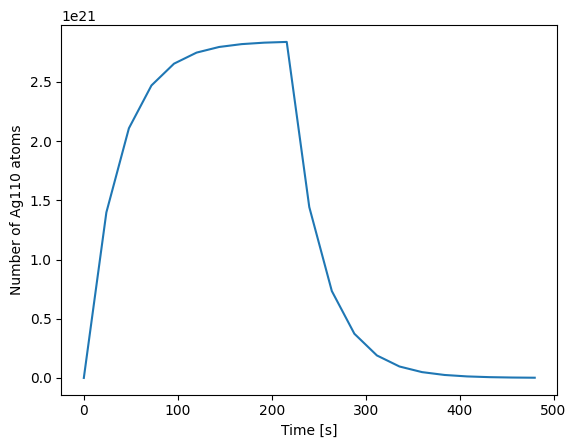

In [17]:
plt.plot(times, number_of_Ag110_atoms)
plt.xlabel('Time [s]')
plt.ylabel('Number of Ag110 atoms')
plt.show()